# Malaysia Brand Campaign Reaction Dataset Builder

This notebook builds a dataset for the topic: customer feedback and public reactions to Malaysian brand campaigns / promotions.

Current brands: Touch 'n Go eWallet, GXBank, and Shopee Malaysia.

Recommended approach:

1. Scrape public Reddit comments from campaign-specific discussion threads.
2. Save the raw scraped comments before filtering.
3. Add extra manually copied public comments only when they are directly relevant to the campaign/promotion.
4. Mark each comment as `relevant` or `irrelevant` using the relevance criteria below.
5. Keep only relevant campaign reactions for sentiment labeling.
6. Manually label sentiment as `positive`, `neutral`, or `negative`.
7. Add aspect labels later during ABSA/manual labeling, not during scraping.

Important methodology note:

Social media comments may contain music reactions, memes, tagging friends, jokes, or unrelated conversation. These comments should be kept in the raw file but excluded from the final cleaned dataset if they do not discuss the marketing campaign, promotion, offer, trust, discount, cashback, return, app/payment experience, or brand reaction.

Google Play reviews are intentionally not included here because the project topic is marketing/campaign reaction, not general app review sentiment.

In [1]:
# Run once if packages are not installed.
%pip install -q pandas matplotlib openpyxl

In [2]:
import hashlib
import re
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Mount Google Drive when running in Google Colab.
try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount("/content/drive")
except ModuleNotFoundError:
    IN_COLAB = False
    print("Not running in Google Colab. Google Drive mount skipped.")

BRANDS = ["Touch 'n Go eWallet", "GXBank", "Shopee Malaysia"]

if IN_COLAB:
    BASE_DIR = Path("/content/drive/MyDrive/TNL_Data")
else:
    BASE_DIR = Path.cwd() / "TNL_Data"

DATA_DIR = BASE_DIR
DATA_DIR.mkdir(parents=True, exist_ok=True)

MANUAL_INPUT_FILE = DATA_DIR / "manual_campaign_reactions.xlsx"
MANUAL_TEMPLATE_FILE = DATA_DIR / "manual_campaign_reactions_template.csv"

COMBINED_UNFILTERED_FILE = DATA_DIR / "malaysia_brand_campaign_reactions_unfiltered.csv"
FINAL_UNLABELED_FILE = DATA_DIR / "malaysia_brand_campaign_reactions_relevant_unlabeled.csv"
FINAL_LABELING_FILE = DATA_DIR / "malaysia_brand_campaign_reactions_for_manual_labeling.csv"
FINAL_LABELED_FILE = DATA_DIR / "malaysia_brand_campaign_reactions_labeled.csv"

print("Data folder:", DATA_DIR)

Mounted at /content/drive
Data folder: /content/drive/MyDrive/TNL_Data


## 2. Create Manual Collection Template

Run this cell first. It creates a CSV template for comments you manually copy from other public campaign sources.

Manual copy-and-paste is acceptable when:

- the source is public;
- the comment is directly related to the campaign/promotion;
- the source URL is recorded;
- usernames/private details are not collected;
- the collection method is clearly marked, for example `manual_reddit`.

You can fill it in Excel, then save your filled version as either:

- `manual_campaign_reactions.xlsx`
- `manual_campaign_reactions.csv`

Put the file inside the `Data` folder.

In [3]:
manual_columns = [
    "brand",
    "campaign_name",
    "source_platform",
    "source_url",
    "source_comment_url",
    "collection_method",
    "comment_text",
    "relevance_manual",
    "relevance_reason",
    "sentiment_manual",
    "aspect_manual",
    "date_collected",
    "notes",
]

template_df = pd.DataFrame([
    {
        "brand": "Shopee Malaysia",
        "campaign_name": "Shopee Money+ 6% p.a. promotion",
        "source_platform": "Reddit",
        "source_url": "https://www.reddit.com/r/MalaysianPF/comments/1ruyc76/whats_your_thoughts_on_shopee_money_6pa_promotion/",
        "source_comment_url": "Optional: paste direct comment permalink if available",
        "collection_method": "manual_reddit",
        "comment_text": "Paste one public campaign reaction/comment here",
        "relevance_manual": "relevant / irrelevant",
        "relevance_reason": "Example: discusses promo cap / safety / return / misleading discount / music comment / meme only",
        "sentiment_manual": "positive / neutral / negative",
        "aspect_manual": "leave blank first; fill later during ABSA labeling",
        "date_collected": str(date.today()),
        "notes": "Do not store username; optional notes only",
    },
    {
        "brand": "Shopee Malaysia",
        "campaign_name": "Shopee misleading discounts discussion",
        "source_platform": "Reddit",
        "source_url": "https://www.reddit.com/r/singapore/comments/1fpoqbc/misleading_discounts_by_shopee/",
        "source_comment_url": "Optional: paste direct comment permalink if available",
        "collection_method": "manual_reddit",
        "comment_text": "Paste one public campaign reaction/comment here",
        "relevance_manual": "relevant / irrelevant",
        "relevance_reason": "Example: discusses misleading price / discount mechanics / voucher terms",
        "sentiment_manual": "positive / neutral / negative",
        "aspect_manual": "leave blank first; fill later during ABSA labeling",
        "date_collected": str(date.today()),
        "notes": "Singapore source; mention as regional Shopee campaign discussion if used",
    },
])

if not MANUAL_TEMPLATE_FILE.exists():
    template_df.to_csv(MANUAL_TEMPLATE_FILE, index=False, encoding="utf-8-sig")

print("Manual template:")
print(MANUAL_TEMPLATE_FILE)
template_df

Manual template:
/content/drive/MyDrive/TNL_Data/manual_campaign_reactions_template.csv


,brand,campaign_name,source_platform,source_url,source_comment_url,collection_method,comment_text,relevance_manual,relevance_reason,sentiment_manual,aspect_manual,date_collected,notes
0,Shopee Malaysia,Shopee Money+ 6% p.a. promotion,Reddit,https://www.reddit.com/r/MalaysianPF/comments/...,Optional: paste direct comment permalink if av...,manual_reddit,Paste one public campaign reaction/comment here,relevant / irrelevant,Example: discusses promo cap / safety / return...,positive / neutral / negative,leave blank first; fill later during ABSA labe...,2026-06-24,Do not store username; optional notes only
1,Shopee Malaysia,Shopee misleading discounts discussion,Reddit,https://www.reddit.com/r/singapore/comments/1f...,Optional: paste direct comment permalink if av...,manual_reddit,Paste one public campaign reaction/comment here,relevant / irrelevant,Example: discusses misleading price / discount...,positive / neutral / negative,leave blank first; fill later during ABSA labe...,2026-06-24,Singapore source; mention as regional Shopee c...


## 3. Relevance and Labeling Criteria

Use this section as the rulebook for manual filtering and labeling.

Keep a comment if it discusses at least one of these:

- promotion, voucher, cashback, discount, interest/return, reward, or campaign mechanic;
- campaign trust, safety, PIDM/protection, misleading claim, terms and conditions;
- app/payment experience related to the campaign;
- brand reaction caused by the campaign.

Remove or mark `irrelevant` if it is mainly:

- music reaction;
- meme/joke only;
- emoji only;
- tagging friends only;
- spam or unrelated promotion;
- unrelated conversation with no campaign opinion.

Suggested sentiment rules:

- `positive`: supports the campaign, says it is useful/worthwhile/good value/safe enough.
- `neutral`: asks questions, explains terms, compares options, or has no clear positive/negative stance.
- `negative`: says it is misleading, not worth it, unsafe, untrustworthy, troublesome, or disappointing.

## 4. Helper Functions

In [4]:
RELEVANCE_VALUES = {"relevant", "irrelevant", ""}
SENTIMENT_VALUES = {"positive", "neutral", "negative", ""}

CAMPAIGN_RELEVANCE_KEYWORDS = [
    "promo", "promotion", "campaign", "voucher", "cashback", "discount", "deal", "offer",
    "reward", "coins", "return", "interest", "p.a", "pa", "6%", "3%", "rate", "cap", "capped",
    "rm", "money+", "goinvest", "go+", "gxbank", "shopee", "tng", "touch n go",
    "safe", "safety", "pidm", "protected", "trust", "misleading", "terms", "t&c",
    "fee", "hidden charge", "withdraw", "deposit", "payment", "reload", "wallet",
]

IRRELEVANT_HINT_KEYWORDS = [
    "song", "music", "bgm", "soundtrack", "first", "lol", "haha", "tagged", "follow me",
]


def clean_text(text):
    text = str(text or "")
    text = re.sub(r"https?://\S+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def anonymize(value):
    value = str(value or "").strip().lower()
    if not value:
        return ""
    return hashlib.sha256(value.encode("utf-8")).hexdigest()[:12]


def make_id(prefix, number):
    return f"{prefix}{number:04d}"


def relevance_hint(text):
    lowered = clean_text(text).lower()
    if not lowered:
        return "empty"
    relevant_hits = [kw for kw in CAMPAIGN_RELEVANCE_KEYWORDS if kw in lowered]
    irrelevant_hits = [kw for kw in IRRELEVANT_HINT_KEYWORDS if kw in lowered]
    if relevant_hits:
        return "likely_relevant: " + ", ".join(relevant_hits[:5])
    if irrelevant_hits:
        return "possibly_irrelevant: " + ", ".join(irrelevant_hits[:5])
    return "needs_manual_review"


def normalize_label(value, allowed_values):
    value = str(value or "").strip().lower()
    return value if value in allowed_values else ""


def normalize_manual_df(df):
    df = df.copy()
    for col in manual_columns:
        if col not in df.columns:
            df[col] = ""
    df = df[manual_columns]
    df["brand"] = df["brand"].fillna("").astype(str).str.strip()
    df["collection_method"] = df["collection_method"].replace("", "manual").fillna("manual")
    df["comment_text"] = df["comment_text"].apply(clean_text)
    df["relevance_manual"] = df["relevance_manual"].apply(lambda x: normalize_label(x, RELEVANCE_VALUES))
    df["sentiment_manual"] = df["sentiment_manual"].apply(lambda x: normalize_label(x, SENTIMENT_VALUES))
    return df[df["comment_text"].str.len() >= 5]


def relevant_only(df):
    df = df.copy()
    df["relevance_manual"] = df["relevance_manual"].fillna("").str.lower().str.strip()
    # Blank relevance is kept for the labeling file because it still needs manual review.
    # For the final cleaned dataset, use only rows explicitly marked relevant.
    return df[df["relevance_manual"].eq("relevant")].copy()

## 5. Load Optional Manually Collected Comments

Optional: put your filled manual file in the `Data` folder. The notebook will look for:

1. `manual_campaign_reactions.xlsx`
2. `manual_campaign_reactions.csv`

Use one row per public comment/reaction.

For Reddit comments, recommended values:

- `source_platform`: `Reddit`
- `collection_method`: `manual_reddit`
- `source_url`: Reddit post URL
- `source_comment_url`: direct comment permalink if available
- `notes`: do not include username; include only source/context notes

In [5]:
manual_xlsx = DATA_DIR / "manual_campaign_reactions.xlsx"
manual_csv = DATA_DIR / "manual_campaign_reactions.csv"

if manual_xlsx.exists():
    manual_df = pd.read_excel(manual_xlsx)
    print(f"Loaded manual Excel file: {manual_xlsx}")
elif manual_csv.exists():
    manual_df = pd.read_csv(manual_csv)
    print(f"Loaded manual CSV file: {manual_csv}")
else:
    manual_df = pd.DataFrame(columns=manual_columns)
    print("No manual file found yet. Fill the template first, then rerun this notebook.")

manual_df = normalize_manual_df(manual_df)
print(f"Manual comments loaded: {len(manual_df)}")
manual_df.head()

No manual file found yet. Fill the template first, then rerun this notebook.
Manual comments loaded: 0


,brand,campaign_name,source_platform,source_url,source_comment_url,collection_method,comment_text,relevance_manual,relevance_reason,sentiment_manual,aspect_manual,date_collected,notes


## 6. Scrape Reddit Campaign Comments

This cell scrapes public Reddit comments from the selected campaign discussion links.

Direct Reddit `.json` often returns 403, so this notebook uses the public PullPush Reddit archive API to collect archived public comments. The output follows the same columns as the rest of the dataset, but `sentiment_manual` and `aspect_manual` are left blank for later manual labeling.

Important: usernames are not stored. The notebook stores only hashed author IDs in `notes` for duplicate/audit purposes.
During scraping, obvious non-English / unreadable spam comments are skipped automatically and written to `reddit_campaign_comments_removed_language_noise.csv` for audit. Short English comments are not removed here; relevance is still reviewed later.

If the PullPush API returns 502 or is temporarily unavailable, this cell retries automatically. If scraping still returns zero rows but an older raw CSV exists, the notebook loads the existing raw CSV instead of overwriting it with an empty file.


In [6]:
import html
import json
import time
import urllib.parse
import urllib.request

REDDIT_RAW_FILE = DATA_DIR / "reddit_campaign_comments_raw.csv"
REDDIT_LANGUAGE_REMOVED_FILE = DATA_DIR / "reddit_campaign_comments_removed_language_noise.csv"
MAX_COMMENTS_PER_REDDIT_THREAD = 500

REDDIT_SOURCES = [
    {
        "brand": "Shopee Malaysia",
        "campaign_name": "Shopee Free Shipping wording discussion",
        "url": "https://www.reddit.com/r/malaysia/comments/y0dq2y/does_shopee_actually_understand_what_is_free/",
    },
    {
        "brand": "Shopee Malaysia",
        "campaign_name": "Shopee scammy voucher mechanics discussion",
        "url": "https://www.reddit.com/r/malaysia/comments/zj44il/how_are_blatantly_scammy_shopee_vouchers_like/",
    },
    {
        "brand": "Shopee Malaysia",
        "campaign_name": "Shopee misleading discounts discussion",
        "url": "https://www.reddit.com/r/singapore/comments/1fpoqbc/misleading_discounts_by_shopee/",
    },
    {
        "brand": "Shopee Malaysia",
        "campaign_name": "Shopee BNPL / SPayLater push discussion",
        "url": "https://www.reddit.com/r/malaysia/comments/1okczbv/why_shopee_try_so_hard_to_push_buy_now_pay_later/",
    },
    {
        "brand": "Shopee Malaysia",
        "campaign_name": "Shopee dynamic pricing strategy discussion",
        "url": "https://www.reddit.com/r/Bolehland/comments/1to2ngu/anyone_else_absolutely_hate_shopees_dynamic/",
    },
    {
        "brand": "Shopee Malaysia",
        "campaign_name": "Shopee Free Shipping voucher RM3 cap discussion",
        "url": "https://www.reddit.com/r/malaysia/comments/vhg7yo/shopee_free_shipping_vouchers_are_now_capped_at/",
    },
    {
        "brand": "Touch 'n Go eWallet",
        "campaign_name": "TNG eWallet user backlash discussion",
        "url": "https://www.reddit.com/r/Bolehland/comments/1pcwqtp/many_people_upset_about_tngo/",
    },
    {
        "brand": "GXBank",
        "campaign_name": "GXBank interest rate cut to 2.0% discussion",
        "url": "https://www.reddit.com/r/malaysia/comments/1fa5bi3/gx_bank_cut_their_interest_rate_to_20_for_main/",
    },
    {
        "brand": "Shopee Malaysia",
        "campaign_name": "Shopee RM25 deals discussion",
        "url": "https://www.reddit.com/r/malaysia/comments/wwk1ec/has_anyone_ever_gotten_those_rm25_deals_shopee/",
    },
    {
        "brand": "GXBank / Boost Bank",
        "campaign_name": "GXBank or Boost Bank savings comparison discussion",
        "url": "https://www.reddit.com/r/MalaysianPF/comments/1mta7fy/gx_bank_or_boost_bank_for_savings/",
    },

    {
        "brand": "Maybank",
        "campaign_name": "Maybank first credit card cashback recommendation discussion",
        "url": "https://www.reddit.com/r/MalaysianPF/comments/1im0kxo/my_1st_credit_card_which_should_i_get/",
    },
    {
        "brand": "Maybank",
        "campaign_name": "Maybank credit card recommendation discussion",
        "url": "https://www.reddit.com/r/MalaysianPF/comments/11guaz1/any_good_credit_card_recommendations_as_maybank/",
    },
    {
        "brand": "Maybank",
        "campaign_name": "Maybank Amex weekend cashback discussion",
        "url": "https://www.reddit.com/r/MalaysianPF/comments/1koszb6/need_advise_on_credit_card/",
    },
    {
        "brand": "CIMB",
        "campaign_name": "CIMB MY-SG transfer and FastSaver recommendation discussion",
        "url": "https://www.reddit.com/r/MalaysianPF/comments/1gin3wd/best_bank_in_singapore_for_malaysian_worker/",
    },
    {
        "brand": "CIMB",
        "campaign_name": "CIMB MY-SG transfer cost saving discussion",
        "url": "https://www.reddit.com/r/MalaysianPF/comments/zvjw1o/financial_advice_for_rm93_k_salary/",
    },
    {
        "brand": "CIMB",
        "campaign_name": "CIMB eCard bonus points cashback discussion",
        "url": "https://www.reddit.com/r/MalaysianPF/comments/yk9bx3/interesting_hack_found_on_ziet_invests_new_vids/",
    },
    {
        "brand": "Public Bank",
        "campaign_name": "Public Bank Quantum cashback discussion",
        "url": "https://www.reddit.com/r/MalaysianPF/comments/keg87p/anyone_checked_bsn_visa_card_yet/",
    },
    {
        "brand": "Public Bank",
        "campaign_name": "Public Bank cashback credit card discussion",
        "url": "https://www.reddit.com/r/MalaysianPF/comments/rqfrgu/best_credit_card_to_apply_for/",
    },
    {
        "brand": "Public Bank",
        "campaign_name": "Public Bank credit card reward discussion",
        "url": "https://www.reddit.com/r/MalaysianPF/comments/zhn3v0/which_bank_is_more_lenient_and_approves_higher_cc/",
    },
    {
        "brand": "Lazada Malaysia",
        "campaign_name": "Lazada vs Shopee preference and return policy discussion",
        "url": "https://www.reddit.com/r/malaysia/comments/101fttz/reddit_of_malaysia_which_ecommerce_app_do_you/",
    },
    {
        "brand": "Lazada Malaysia",
        "campaign_name": "Lazada shipping refund voucher positive discussion",
        "url": "https://www.reddit.com/r/malaysia/comments/15jnioe/the_straw_that_broke_the_camels_back/",
    },
]

# Direct comment permalinks were used to identify these positive source threads.
# The notebook now scrapes the full Reddit posts above, so this target-only list is disabled
# to avoid duplicating selected comments.
REDDIT_TARGET_COMMENT_SOURCES = []

REDDIT_RELEVANCE_KEYWORDS = [
    "free shipping", "voucher", "vouchers", "cashback", "discount", "deal", "deals", "rm25", "rm 25",
    "promotion", "promo", "cap", "capped", "minimum spend", "shipping", "spaylater", "paylater", "bnpl",
    "dynamic pricing", "price", "misleading", "scammy", "scam", "trust", "t&c", "terms", "fee", "charge",
    "interest", "rate", "2.0", "3%", "return", "refund", "return policy", "delivery", "shipping",
    "savings", "gxbank", "boost bank", "tngo", "tng", "touch n go", "touch 'n go",
    "ewallet", "wallet", "reload", "withdraw", "account", "bank", "credit card", "amex",
    "maybank", "cimb", "public bank", "pbb", "lazada", "points", "bonus points", "reliable",
]

REMOVED_MARKERS = {"[deleted]", "[removed]", "deleted", "removed"}

# Keep this filter conservative. It removes obvious non-English / unreadable spam only.
# Relevance and sentiment are reviewed later.
NON_ENGLISH_REMOVE_PATTERNS = [
    (r"\b(bagus\s+){5,}", "repeated_non_english_meme_text"),
    (r"^\s*bodo\s+piang\s*$", "non_english_slang_only"),
    (r"^\s*saupei\s+penipu\s+scammer\.?\s*$", "mostly_non_english_slang"),
    (r"langsung\s+takde\s+kaitan", "mostly_non_english_off_topic"),
]


def clean_reddit_text(text):
    text = html.unescape(str(text or ""))
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"(^|\s)>\s*", " ", text)
    text = re.sub(r"[`*_~^]+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def language_filter_decision(text):
    cleaned = clean_reddit_text(text)
    lowered = cleaned.lower().strip()
    if not lowered:
        return False, "empty_after_cleaning", cleaned
    for pattern, reason in NON_ENGLISH_REMOVE_PATTERNS:
        if re.search(pattern, lowered, flags=re.I):
            return False, reason, cleaned
    return True, "kept_for_relevance_review", cleaned


def extract_reddit_post_id(url):
    match = re.search(r"/comments/([a-z0-9]+)/", url, re.I)
    if not match:
        raise ValueError(f"Cannot extract Reddit post ID: {url}")
    return match.group(1)




def extract_reddit_comment_id(url):
    match = re.search(r"/comment/([a-z0-9]+)/?", url, re.I)
    if match:
        return match.group(1)
    match = re.search(r"/comments/[a-z0-9]+/[^/]+/([a-z0-9]+)/?", url, re.I)
    if match:
        return match.group(1)
    raise ValueError(f"Cannot extract Reddit comment ID: {url}")

def reddit_relevance_hint(text):
    lowered = clean_reddit_text(text).lower()
    hits = [kw for kw in REDDIT_RELEVANCE_KEYWORDS if kw in lowered]
    if hits:
        return "likely_relevant: " + ", ".join(hits[:5])
    return "needs_manual_review"


def request_json(url, max_attempts=3):
    last_error = None
    for attempt in range(1, max_attempts + 1):
        try:
            request = urllib.request.Request(
                url,
                headers={"User-Agent": "Mozilla/5.0 TNL6323 academic dataset collection"},
            )
            with urllib.request.urlopen(request, timeout=40) as response:
                return json.loads(response.read().decode("utf-8", errors="replace"))
        except Exception as error:
            last_error = error
            print(f"    PullPush request failed attempt {attempt}/{max_attempts}: {error}")
            if attempt < max_attempts:
                time.sleep(attempt * 2)
    raise last_error


def fetch_pullpush_comments(post_id, max_comments=500):
    rows = []
    before = None
    while len(rows) < max_comments:
        params = {"link_id": post_id, "size": 100, "sort": "desc", "sort_type": "score"}
        if before:
            params["before"] = before
        url = "https://api.pullpush.io/reddit/comment/search?" + urllib.parse.urlencode(params)
        data = request_json(url)
        batch = data.get("data", [])
        if not batch:
            break

        rows.extend(batch)
        created_values = [item.get("created_utc") for item in batch if item.get("created_utc")]
        if not created_values:
            break
        new_before = min(created_values) - 1
        if before == new_before:
            break
        before = new_before
        time.sleep(0.35)

    return rows[:max_comments]


def make_reddit_comment_url(post_id, comment_id):
    if not comment_id:
        return ""
    return f"https://www.reddit.com/comments/{post_id}/_/{comment_id}/"


reddit_rows = []
removed_language_rows = []

for source in REDDIT_SOURCES:
    post_id = extract_reddit_post_id(source["url"])
    print("Fetching Reddit comments:", source["campaign_name"])

    try:
        comments = fetch_pullpush_comments(post_id, MAX_COMMENTS_PER_REDDIT_THREAD)
    except Exception as error:
        print(f"Could not fetch {source['url']}: {error}")
        comments = []

    seen_text = set()
    kept_count = 0
    removed_count = 0

    for comment in comments:
        raw_text = comment.get("body", "")
        comment_text = clean_reddit_text(raw_text)
        if not comment_text or comment_text.lower() in REMOVED_MARKERS:
            continue
        if len(comment_text) < 5:
            continue

        duplicate_key = comment_text.lower()
        if duplicate_key in seen_text:
            continue
        seen_text.add(duplicate_key)

        comment_id = comment.get("id", "")
        score = comment.get("score", "")
        created_utc = comment.get("created_utc", "")
        subreddit = comment.get("subreddit", "")
        author_hash = anonymize(comment.get("author", ""))
        source_comment_url = make_reddit_comment_url(post_id, comment_id)

        keep_comment, language_reason, cleaned_for_labeling = language_filter_decision(comment_text)
        if not keep_comment:
            removed_count += 1
            removed_language_rows.append({
                "brand": source["brand"],
                "campaign_name": source["campaign_name"],
                "source_platform": "Reddit",
                "source_url": source["url"],
                "source_comment_url": source_comment_url,
                "comment_text": comment_text,
                "language_filter_reason": language_reason,
                "date_collected": str(date.today()),
                "notes": f"post_id={post_id}; comment_id={comment_id}; author_hash={author_hash}; score={score}; created_utc={created_utc}; subreddit={subreddit}",
            })
            continue

        kept_count += 1
        reddit_rows.append({
            "brand": source["brand"],
            "campaign_name": source["campaign_name"],
            "source_platform": "Reddit",
            "source_url": source["url"],
            "source_comment_url": source_comment_url,
            "collection_method": "scraped_reddit_pullpush",
            "comment_text": cleaned_for_labeling,
            "relevance_manual": "",
            "relevance_reason": reddit_relevance_hint(cleaned_for_labeling),
            "sentiment_manual": "",
            "aspect_manual": "",
            "date_collected": str(date.today()),
            "notes": f"post_id={post_id}; comment_id={comment_id}; author_hash={author_hash}; score={score}; created_utc={created_utc}; subreddit={subreddit}",
        })

    print(f"  kept comments: {kept_count}; removed language/noise: {removed_count}")
    time.sleep(0.5)


# Add selected high-quality direct comment permalinks.
# PullPush fetches comments by post, so we fetch each source thread once and keep only the chosen comment IDs.
target_comments_cache = {}
target_seen_comment_ids = set()

if REDDIT_TARGET_COMMENT_SOURCES:
    print("Fetching targeted Reddit comment permalinks:")

for source in REDDIT_TARGET_COMMENT_SOURCES:
    post_id = extract_reddit_post_id(source["source_comment_url"])
    target_comment_id = extract_reddit_comment_id(source["source_comment_url"])

    if target_comment_id in target_seen_comment_ids:
        continue
    target_seen_comment_ids.add(target_comment_id)

    if post_id not in target_comments_cache:
        try:
            target_comments_cache[post_id] = fetch_pullpush_comments(post_id, MAX_COMMENTS_PER_REDDIT_THREAD)
        except Exception as error:
            print(f"Could not fetch targeted source {source['source_comment_url']}: {error}")
            target_comments_cache[post_id] = []

    matching_comments = [comment for comment in target_comments_cache[post_id] if comment.get("id", "") == target_comment_id]
    if not matching_comments:
        print(f"  target comment not found in archive: {source['source_comment_url']}")
        continue

    comment = matching_comments[0]
    raw_text = comment.get("body", "")
    comment_text = clean_reddit_text(raw_text)
    if not comment_text or comment_text.lower() in REMOVED_MARKERS or len(comment_text) < 5:
        print(f"  target comment skipped after cleaning: {source['source_comment_url']}")
        continue

    comment_id = comment.get("id", "")
    score = comment.get("score", "")
    created_utc = comment.get("created_utc", "")
    subreddit = comment.get("subreddit", "")
    author_hash = anonymize(comment.get("author", ""))

    keep_comment, language_reason, cleaned_for_labeling = language_filter_decision(comment_text)
    if not keep_comment:
        removed_language_rows.append({
            "brand": source["brand"],
            "campaign_name": source["campaign_name"],
            "source_platform": "Reddit",
            "source_url": source["url"],
            "source_comment_url": source["source_comment_url"],
            "comment_text": comment_text,
            "language_filter_reason": language_reason,
            "date_collected": str(date.today()),
            "notes": f"target_positive_comment=1; post_id={post_id}; comment_id={comment_id}; author_hash={author_hash}; score={score}; created_utc={created_utc}; subreddit={subreddit}",
        })
        print(f"  target comment removed by language/noise filter: {source['source_comment_url']}")
        continue

    reddit_rows.append({
        "brand": source["brand"],
        "campaign_name": source["campaign_name"],
        "source_platform": "Reddit",
        "source_url": source["url"],
        "source_comment_url": source["source_comment_url"],
        "collection_method": "scraped_reddit_pullpush_target_comment",
        "comment_text": cleaned_for_labeling,
        "relevance_manual": "",
        "relevance_reason": reddit_relevance_hint(cleaned_for_labeling),
        "sentiment_manual": "",
        "aspect_manual": "",
        "date_collected": str(date.today()),
        "notes": f"target_positive_comment=1; post_id={post_id}; comment_id={comment_id}; author_hash={author_hash}; score={score}; created_utc={created_utc}; subreddit={subreddit}",
    })
    print(f"  added target comment: {source['brand']} | {source['campaign_name']}")

reddit_df = pd.DataFrame(reddit_rows, columns=manual_columns)
removed_language_df = pd.DataFrame(removed_language_rows)

if len(reddit_df) > 0:
    reddit_df.to_csv(REDDIT_RAW_FILE, index=False, encoding="utf-8-sig")
    removed_language_df.to_csv(REDDIT_LANGUAGE_REMOVED_FILE, index=False, encoding="utf-8-sig")
    print(f"Total Reddit comments after language filter: {len(reddit_df)}")
    print(f"Removed language/noise comments: {len(removed_language_df)}")
    print("Reddit raw file:", REDDIT_RAW_FILE)
    print("Removed language/noise file:", REDDIT_LANGUAGE_REMOVED_FILE)
elif REDDIT_RAW_FILE.exists():
    reddit_df = pd.read_csv(REDDIT_RAW_FILE)
    print("WARNING: Reddit scraping returned 0 rows. Loaded existing raw CSV instead:", REDDIT_RAW_FILE)
    print(f"Loaded existing Reddit rows: {len(reddit_df)}")
else:
    print("WARNING: Reddit scraping returned 0 rows and no existing raw CSV was found.")
    print("Do not run the combine/export cell until scraping succeeds or you provide a manual CSV.")

reddit_df.head(10)


Fetching Reddit comments: Shopee Free Shipping wording discussion
Could not fetch https://www.reddit.com/r/malaysia/comments/y0dq2y/does_shopee_actually_understand_what_is_free/: HTTP Error 502: Bad Gateway
  kept comments: 0; removed language/noise: 0
Fetching Reddit comments: Shopee scammy voucher mechanics discussion
Could not fetch https://www.reddit.com/r/malaysia/comments/zj44il/how_are_blatantly_scammy_shopee_vouchers_like/: HTTP Error 502: Bad Gateway
  kept comments: 0; removed language/noise: 0
Fetching Reddit comments: Shopee misleading discounts discussion
Could not fetch https://www.reddit.com/r/singapore/comments/1fpoqbc/misleading_discounts_by_shopee/: HTTP Error 502: Bad Gateway
  kept comments: 0; removed language/noise: 0
Fetching Reddit comments: Shopee BNPL / SPayLater push discussion
Could not fetch https://www.reddit.com/r/malaysia/comments/1okczbv/why_shopee_try_so_hard_to_push_buy_now_pay_later/: HTTP Error 502: Bad Gateway
  kept comments: 0; removed language/n

,brand,campaign_name,source_platform,source_url,source_comment_url,collection_method,comment_text,relevance_manual,relevance_reason,sentiment_manual,aspect_manual,date_collected,notes


## 7. Combine Raw/Scraped and Manual Data

This exports two files:

1. `malaysia_brand_campaign_reactions_unfiltered.csv` keeps all collected comments.
2. `malaysia_brand_campaign_reactions_for_manual_labeling.csv` is the working file where you mark `relevance_manual`, `sentiment_manual`, and `aspect_manual`.

Do not delete raw/unfiltered rows. Mark irrelevant rows instead, so the report can explain the filtering process.

In [7]:
dataframes_to_combine = []
for candidate_name in ["reddit_df", "manual_df"]:
    if candidate_name in globals():
        candidate_df = globals()[candidate_name]
        if isinstance(candidate_df, pd.DataFrame) and len(candidate_df) > 0:
            dataframes_to_combine.append(candidate_df)

if dataframes_to_combine:
    combined_df = pd.concat(dataframes_to_combine, ignore_index=True)
else:
    combined_df = pd.DataFrame(columns=manual_columns)

if len(combined_df) > 0:
    combined_df["comment_text"] = combined_df["comment_text"].apply(clean_text)
    combined_df = combined_df[combined_df["comment_text"].str.len() >= 5]
    combined_df = combined_df.drop_duplicates(subset=["comment_text", "campaign_name", "source_platform", "source_url"])
    combined_df = combined_df.reset_index(drop=True)
    if "id" in combined_df.columns:
        combined_df = combined_df.drop(columns=["id"])
    combined_df.insert(0, "id", [make_id("MYB", i + 1) for i in range(len(combined_df))])

    combined_df.to_csv(COMBINED_UNFILTERED_FILE, index=False, encoding="utf-8-sig")
    combined_df.to_csv(FINAL_LABELING_FILE, index=False, encoding="utf-8-sig")
    print(f"Combined unfiltered rows: {len(combined_df)}")
    print("Unfiltered dataset:", COMBINED_UNFILTERED_FILE)
    print("Manual relevance/sentiment labeling file:", FINAL_LABELING_FILE)
elif FINAL_LABELING_FILE.exists():
    combined_df = pd.read_csv(FINAL_LABELING_FILE)
    print("WARNING: Combined data is empty. Loaded existing manual-labeling CSV instead:", FINAL_LABELING_FILE)
    print(f"Loaded existing rows: {len(combined_df)}")
else:
    print("WARNING: Combined data is empty and no existing labeling CSV was found. Nothing was exported.")

combined_df.head(10)


Combined unfiltered rows: 0
Unfiltered dataset: /content/drive/MyDrive/TNL_Data/malaysia_brand_campaign_reactions_unfiltered.csv
Manual relevance/sentiment labeling file: /content/drive/MyDrive/TNL_Data/malaysia_brand_campaign_reactions_for_manual_labeling.csv


,id,brand,campaign_name,source_platform,source_url,source_comment_url,collection_method,comment_text,relevance_manual,relevance_reason,sentiment_manual,aspect_manual,date_collected,notes


## 8. Filter Relevant Campaign Reactions

After you fill `relevance_manual` in the manual labeling file, run this cell.

Only rows marked `relevant` are exported to the final unlabeled dataset for sentiment training.

In [8]:
if FINAL_LABELING_FILE.exists():
    review_df = pd.read_csv(FINAL_LABELING_FILE)
    review_df["relevance_manual"] = review_df["relevance_manual"].fillna("").str.lower().str.strip()
    relevant_df = review_df[review_df["relevance_manual"].eq("relevant")].copy()
    irrelevant_df = review_df[review_df["relevance_manual"].eq("irrelevant")].copy()
    pending_df = review_df[review_df["relevance_manual"].eq("")].copy()

    relevant_df.to_csv(FINAL_UNLABELED_FILE, index=False, encoding="utf-8-sig")

    print(f"Relevant rows: {len(relevant_df)}")
    print(f"Irrelevant rows: {len(irrelevant_df)}")
    print(f"Pending relevance review: {len(pending_df)}")
    print("Relevant-only unlabeled dataset:", FINAL_UNLABELED_FILE)

    display(review_df["relevance_manual"].replace("", "pending").value_counts().to_frame("count"))
else:
    print("Manual labeling file does not exist yet. Run the combine cell first.")

Relevant rows: 0
Irrelevant rows: 0
Pending relevance review: 0
Relevant-only unlabeled dataset: /content/drive/MyDrive/TNL_Data/malaysia_brand_campaign_reactions_relevant_unlabeled.csv


,count
relevance_manual,


## 9. Check Source Balance

This helps you explain the data collection method in the report.

,count
collection_method,


,count
source_platform,


,count
brand,


IndexError: index 0 is out of bounds for axis 0 with size 0

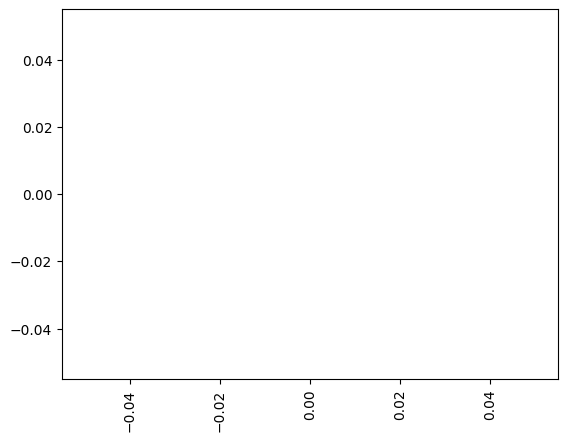

In [10]:
source_check_file = FINAL_LABELING_FILE if FINAL_LABELING_FILE.exists() else COMBINED_UNFILTERED_FILE

if source_check_file.exists():
    source_df = pd.read_csv(source_check_file)
    if not source_df.empty:
        display(source_df["collection_method"].value_counts().to_frame("count"))
        display(source_df["source_platform"].value_counts().to_frame("count"))
        display(source_df["brand"].value_counts().to_frame("count"))

        collection_method_counts = source_df["collection_method"].value_counts()
        if not collection_method_counts.empty:
            ax = collection_method_counts.plot(kind="bar", color="#2f6f8f")
            ax.set_title("Dataset Collection Method")
            ax.set_xlabel("Collection Method")
            ax.set_ylabel("Number of Comments")
            plt.xticks(rotation=20, ha="right")
            plt.tight_layout()
            plt.show()
        else:
            print("No collection method data to plot.")
    else:
        print("The DataFrame loaded from source_check_file is empty. No data to display or plot.")
else:
    print("No data yet. Run the Reddit scraping cell or fill the manual template.")